In [7]:
#MOana specific
import os, subprocess
print("PID:", os.getpid())
print("CUDA_VISIBLE_DEVICES:", os.environ.get("CUDA_VISIBLE_DEVICES"))
print("hostname:", subprocess.run(["hostname"], capture_output=True, text=True).stdout.strip())
print(subprocess.run(["nvidia-smi", "-L"], capture_output=True, text=True).stdout)


PID: 242566
CUDA_VISIBLE_DEVICES: None
hostname: cf331f7aa4bc
GPU 0: NVIDIA TITAN X (Pascal) (UUID: GPU-3f2d65bc-b02a-fda5-51fc-72ed6e13beed)
GPU 1: NVIDIA TITAN X (Pascal) (UUID: GPU-d3a09050-15e1-11e6-e9ca-02fad034f13a)
GPU 2: NVIDIA TITAN X (Pascal) (UUID: GPU-445803e7-81b2-f9b2-fb68-27d1e934937a)
GPU 3: NVIDIA TITAN X (Pascal) (UUID: GPU-6044dc59-ec99-d562-5689-4099eb7024b0)



In [8]:

#MOANA ONLY
#os.environ["CUDA_VISIBLE_DEVICES"] = "1"
#check for errors
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"


In [38]:

# Cell 0 — CONFIG
from pathlib import Path
import numpy as np
%load_ext autoreload
%autoreload 2
import sys, os
from dotenv import load_dotenv
if sys.platform == "win32":
    project_root = Path(r"F:/MScPROJECT_LOCAL")
else:
    _linux_candidates = [Path("/knuckles_drive"), Path("/workspaces/MScPROJECT_LOCAL")]
    for _candidate in _linux_candidates:
        if _candidate.exists():
            project_root = _candidate
            break
    else:
        raise FileNotFoundError(f"None of the known project_root paths exist: {_linux_candidates}")
load_dotenv(project_root / ".env")
case_name = "07_Tropea_cafe"

experiment = "cat_03_6int_lores"

asset_name = f"{case_name}_{experiment}"
from A_Config import set_case
set_case(case_name, experiment)


#These neeed work
case_dir     = project_root / "Data" / case_name
source_dir   = case_dir     / "010_source"
query_dir    = case_dir     / "012_Gemini_outputs"
yolo_masks_dir = case_dir   / "015_YOLO" / experiment
#temp delete sub folder
frames_for_cam_poses = case_dir / "020_frames_for_cam_poses" 
frames_for_recon   = case_dir   / "020_frames_for_recon" / experiment 
VGGT_O_output_dir   = case_dir   /"035_VGGT_O_output"/experiment
predictions_path_256 =  case_dir   /  "035_VGGT_O_output"/"cat_03_6int_lores" /"predictions.npz" 
ply_dir             =   VGGT_O_output_dir  /"ply"         
#temp - need to sort out a unified place? no visualisation is justfor me
reg_dir        = case_dir     / "030_Registrations"
csv_path_GPS = case_dir     / "000_GPS_Data" / "GPS_tags.csv"
csv_path_pose = reg_dir     /"camera_poses.csv"


FRAME_NAME_FMT = "{:04d}.jpg"

#TEMP
#This needs to be filed after user input decides on what to analyse
ppt_template = '03_Version_1'

# video loading
# Auto-find the video in 010_source
videos = list(source_dir.glob("*.mp4"))
assert len(videos) == 1, f"Expected 1 video, found {len(videos)}: {videos}"
video_path = videos[0]
print(f"Case    : {case_name}")
print(f"Video   : {video_path.name}")

#reporting
from C_CSV_report import add_to_report
overview = {
    "Video_name"      : video_path.name, 
    "Title"      : f"{case_name}_{experiment}"
}
add_to_report(overview)
api_key = os.getenv("STREETVIEW_API_KEY")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Case    : 07_Tropea_cafe
Video   : VID_20260530_113822990.mp4


In [35]:
#FLAGS
VID_TO_TEXT     = True
TRACKING        = True
FRAME_SELECTION = True
RECON_CAM_POSES = True
RECON_3D        = True
CUT3R_RECON     = True
MEGA_SAM_RECON  = False
VGGT_RECON      = False
VGGT_O_RECON    = True
MULTI_PART_RECON = False
GOOGLE_MAP      = True
PROJECTION_MAP  = True
MAKE_MOVIE      = True

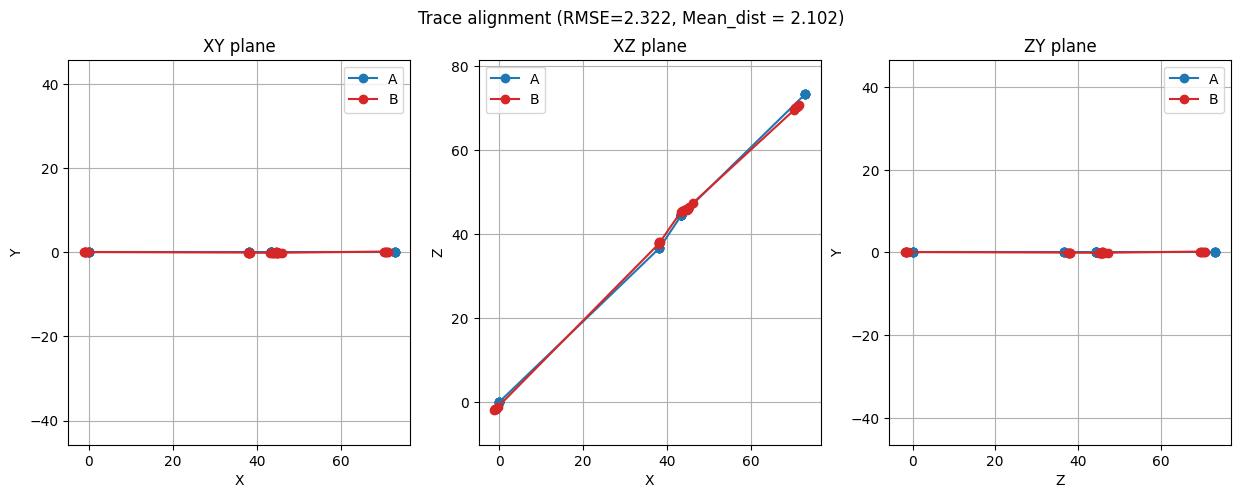

In [11]:
#convert CAMERA POSES from RS model-world-space (set to CAM0) into real-world-space 
if RECON_CAM_POSES == True and VGGT_O_RECON ==True:
    
    #get lat lon positions
    #get transforms to convert other things too
    from Q_Metric_georeferencing import model_to_GPS_calibrated_locations
    cam_poses_realworld_dict, cam_latlons, R_cw, s_cw, t_cw, lat_0, lon_0 = model_to_GPS_calibrated_locations (csv_path_GPS, csv_path_pose)
else:
    print("Cell disabled")



In [12]:
#VGGT OMEGA 
# Cell — VGGT-Omega reconstruction across multiple GPUs
if VGGT_O_RECON == True and RECON_3D == True and MULTI_PART_RECON == False:
    import gc, torch
    gc.collect()
    torch.cuda.empty_cache()

    import sys
    sys.path.insert(0, str(project_root / "src"))

    from B_VGGT_O_shards import run_vggt_omega_shards

    recon_out = case_dir / "035_VGGT_O_output" / experiment

    run_vggt_omega_shards(
        image_dir              = str(frames_for_recon),
        output_dir             = str(recon_out),
        checkpoint_path        = str(project_root / "Models" / "vggt-omega" / "checkpoints" / "VGGT-Omega-1B-512" / "vggt_omega_1b_512.pt"),
        vggt_omega_shards_dir  = str(project_root / "Models" / "vggt-omega-shards"),
        devices                = ["cuda:0", "cuda:1", "cuda:2", "cuda:3"],
        image_resolution       = 256,
        conf_thres             = 20.0,
        max_points             = 0,
        show_cam               = True,
    )
else:
    print("Cell disabled")   
    

92 frames across 4 GPUs: ['cuda:0', 'cuda:1', 'cuda:2', 'cuda:3']
Running aggregator on 92 frames at 256px across 4 GPUs...
Aggregator done in 81.8s
Predicting camera poses...
Camera head done in 0.2s
Predicting depth maps...
Depth head done in 0.6s
Saved: /workspaces/MScPROJECT_LOCAL/Data/07_Tropea_cafe/035_VGGT_O_output/cat_03_6int_lores/predictions.npz
Saved: /workspaces/MScPROJECT_LOCAL/Data/07_Tropea_cafe/035_VGGT_O_output/cat_03_6int_lores/predictions.glb


Subject VGGT-O → real-world: 21 pairs, RMSE = 1.0501 m
rescale to realwoirld 11.485764219586896
[3854, 3860, 3866, 3872, 3878, 3884, 3890, 3893, 3902, 3908, 3914, 3920, 3924, 3932, 3938, 3944, 3950, 3956, 3962, 3968, 3974, 3980, 3986, 3992, 3998, 4004, 4010, 4016, 4022, 4028, 4034, 4040, 4046, 4052, 4058, 4064, 4070, 4076, 4082, 4088, 4094, 4100, 4106, 4112, 4118, 4124, 4130, 4136, 4142, 4148, 4154, 4160, 4166, 4172, 4178, 4184, 4190, 4196, 4202, 4208, 4214, 4220, 4226, 4232, 4238, 4244, 4250, 4256, 4262, 4268, 4274, 4280, 4286, 4292, 4298, 4304, 4310, 4316, 4322, 4328, 4334, 4337, 4343, 4349, 4358, 4361, 4373, 4379, 4382, 4388, 4394, 4397]
/workspaces/MScPROJECT_LOCAL/Data/07_Tropea_cafe/035_VGGT_O_output/cat_03_6int_lores/predictions.npz
subject moved 6.7127108579703325 m
subject moved in a 203.35078641374798 direction
Auto-zoom: 19, centre (38.67586, 15.89581)
Fetching map...
  Fetching: https://maps.googleapis.com/maps/api/staticmap?center=38.67586296091851,15.89580...
Written: /wo

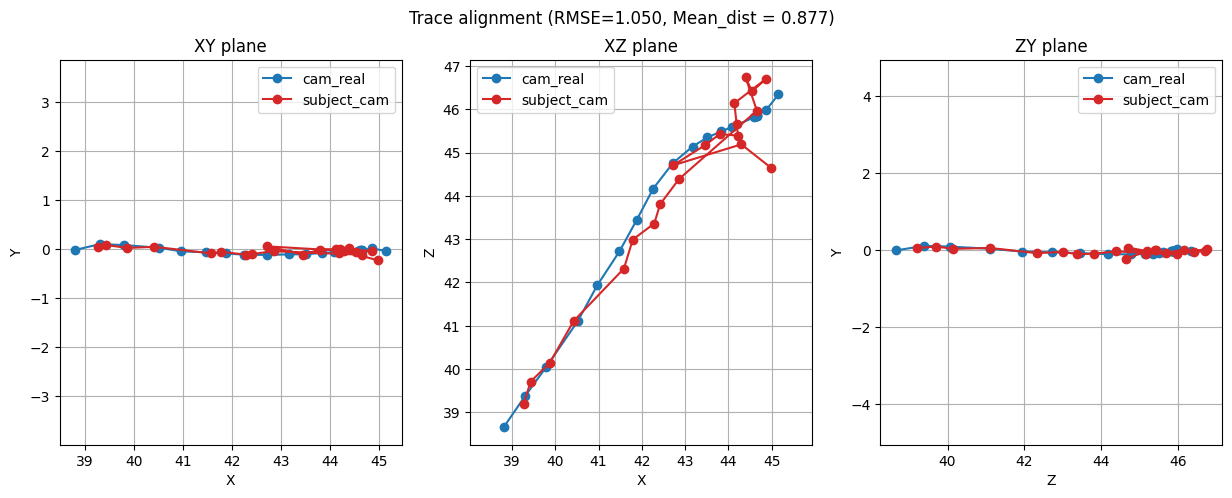

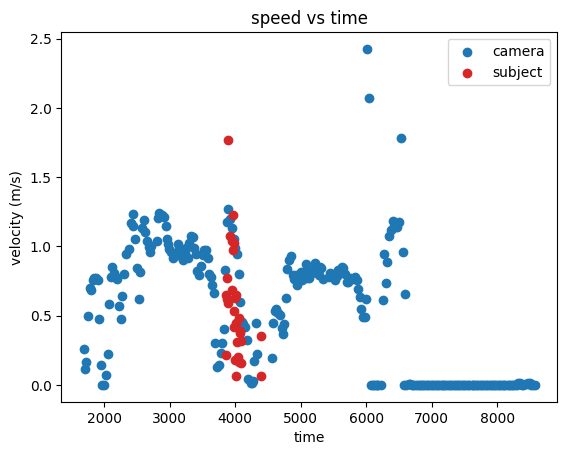

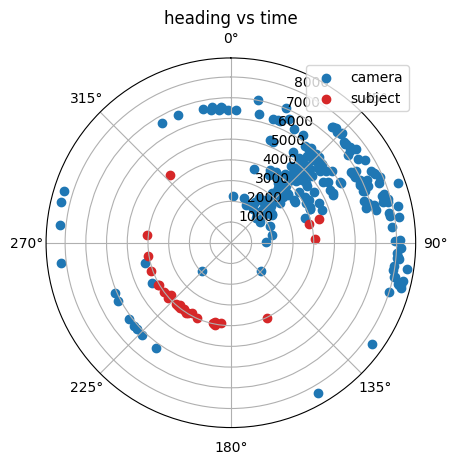

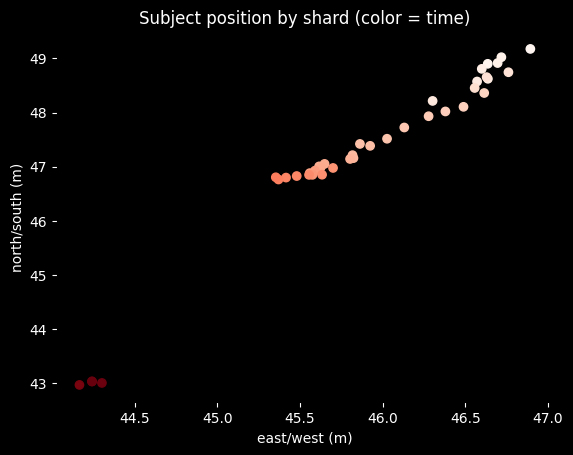

In [37]:
#LOAD VGGT_O recon for further processing
from E_post_recon_processing import Reconstruction
recon_256 = Reconstruction.load(frames_for_recon, predictions_path_256, FRAME_NAME_FMT)
#processes spatial information about the recon and the cubject  - for report and generates the data needed to map the subject
#Takes the lat and long to do mapping
#Takes the cam poses dict to conform the 3d model to the same space that the cam pose transform is in

from Q_subject_analysis import subject_to_metric_and_gps_space
from F_transforms_alignments import  recon_to_recon_transform
R_mw , s_mw, t_mw  = recon_to_recon_transform(recon ,  cam_poses_realworld_dict)
print("rescale to realwoirld",s_mw)
sub_latlon, sub_pos, sub_pos_real_dict = subject_to_metric_and_gps_space(
    recon_256,
    masks_dir        = str(yolo_masks_dir),
    lat_0=lat_0, lon_0=lon_0,
    R_mw=R_mw, s_mw =s_mw, t_mw =t_mw
    )    


        #MAKE PLYS of VGGT__O
        #turn VGGT_O output into cam0 space then scale it to metres using the output from subject_to_metric_and_gps_space
       #n.b it translates to the beginning of the camera track solve, then re-translates to the recon cam 0 space. 
_ = recon_256.VGGT_O_preds_to_ply_export(VGGT_O_output_dir  / "ply" , R=R_mw, t=t_mw, s=s_mw)
        
print(predictions_path_256)
##Graphing and analysis  
from Q_Metric_georeferencing import speed_direction, _speed_direction_single
from Q_subject_analysis import subject_reporting
fps = 30.07 #temp!
#metrics = speed_direction(cam_poses_realworld_dict, fps)
#sub_metrics = speed_direction(sub_pos_real_dict  , fps)
group_metrics = speed_direction((cam_poses_realworld_dict,sub_pos_real_dict),
                                 fps,                                 
                                 )
subject_details =   subject_reporting(sub_pos_real_dict,cam_poses_realworld_dict,lat_0, lon_0 )

#graph postions 2d
from matplotlib import pyplot as plt
# sub_rw_dicts[i] == (sub_latlon_i, sub_pos_i, sub_pos_real_dict_i)
pts = np.array([sub_pos_real_dict[k] for k in sorted(sub_pos_real_dict)])
x_0 = pts[:, 0]
y_0 = pts[:, 2]

#y_0 = sub_pos_real_dict[1][:,2]
#x_0 = sub_pos_real_dict[1][:,0]
#y_1 = sub_rw_dicts[1][1][:,2]
#x_1 = sub_rw_dicts[1][1][:,0]
#y_2 = sub_rw_dicts[2][1][:,2]
#x_2 = sub_rw_dicts[2][1][:,0]
fig, ax = plt.subplots()
fig.patch.set_facecolor("black")
ax.set_facecolor("black")

ax.scatter(x_0, y_0, c=np.arange(len(x_0)), cmap="Reds")
#ax.scatter(x_1, y_1, c=np.arange(len(x_1)), cmap="Greens")
#ax.scatter(x_2, y_2, c=np.arange(len(x_2)), cmap="Blues")

ax.tick_params(colors="white")
ax.xaxis.label.set_color("white")
ax.yaxis.label.set_color("white")
ax.title.set_color("white")
ax.set_xlabel("east/west (m)")
ax.set_ylabel("north/south (m)")
ax.set_title("Subject position by shard (color = time)")

#make animated map can do svg, giof or mp4. SVG is default

import importlib, R_map_animator

R_map_animator.main(
    traces=[
        {"coords": cam_latlons, "trail_color": "#3498db"},#cameras
        {"coords": sub_latlon,    "trail_color": "#e74c3c"},#subject
    ],
    api_key     = api_key,
    gif = True,
    mp4 = None
    

)


In [39]:
#CAMERA TRANSFORMS - single recon at the moment
ext_0 = recon_256.preds["extrinsic"][9].clone()
#1m up
ext_1 = recon_256.preds["extrinsic"][9].clone()
ext_1[1, 3] += 1/16   # lift camera 1m (1/16 scale)

#10m up BEV
ext9 = recon_256.preds["extrinsic"][9]
Rx = torch.tensor([[1., 0., 0.],
                   [0., 0., -1.],
                   [0., 1., 0.]], dtype=ext9.dtype, device=ext9.device)

ext_2 = Rx @ ext9        # pitch 90° down, camera stays where cam 9 was
ext_2[2, 3] += 20/16     # lift 10m (up is -z now that the view axis points down)
ext_2[1, 3] += 5/16      # forward 5m along cam 9's original heading

In [ ]:

#2D projection mapping of subject to a selected view
from E_post_recon_processing import Reconstruction
from P_projection_mapping import projection_mapping_sequence
from Two2D.B_video_processing import available_frames

#Use this to project every frame in the recon
extra_indices = available_frames(frames_for_recon, FRAME_NAME_FMT)
print(extra_indices)

point_cloud_xforms = None

subject_positions = projection_mapping_sequence(
    
    recon         = recon_256,
    main_idx      = None,
    #extra_indices = range (3854,4397),
      #other syntax  [400,4027, 4052, 4065],
    extra_indices = extra_indices, #- for composite (double [[]])
    #masks_dir     = str(yolo_masks_dir),
    new_view = ext_1 ,
    confidence_threshold = 0
    
       )


[3854, 3860, 3866, 3872, 3878, 3884, 3890, 3893, 3902, 3908, 3914, 3920, 3924, 3932, 3938, 3944, 3950, 3956, 3962, 3968, 3974, 3980, 3986, 3992, 3998, 4004, 4010, 4016, 4022, 4028, 4034, 4040, 4046, 4052, 4058, 4064, 4070, 4076, 4082, 4088, 4094, 4100, 4106, 4112, 4118, 4124, 4130, 4136, 4142, 4148, 4154, 4160, 4166, 4172, 4178, 4184, 4190, 4196, 4202, 4208, 4214, 4220, 4226, 4232, 4238, 4244, 4250, 4256, 4262, 4268, 4274, 4280, 4286, 4292, 4298, 4304, 4310, 4316, 4322, 4328, 4334, 4337, 4343, 4349, 4358, 4361, 4373, 4379, 4382, 4388, 4394, 4397]
[3854]
[3860]
[3866]
[3872]
[3878]
[3884]
[3890]
[3893]
[3902]
[3908]
[3914]
[3920]
[3924]
[3932]
[3938]
[3944]
[3950]
[3956]
[3962]
[3968]
[3974]
[3980]
[3986]
[3992]
[3998]
[4004]
[4010]
[4016]
[4022]
[4028]
[4034]
[4040]
[4046]
[4052]
[4058]
[4064]
[4070]
[4076]
[4082]
[4088]
[4094]
[4100]
[4106]
[4112]
[4118]
[4124]
[4130]
[4136]
[4142]
[4148]
[4154]
[4160]
[4166]
[4172]
[4178]
[4184]
[4190]
[4196]
[4202]
[4208]
[4214]
[4220]
[4226]
[4232]

ffmpeg version 7.1.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with gcc 14.3.0 (conda-forge gcc 14.3.0-5)
  configuration: --prefix=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_h_env_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_plac --cc=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-cc --cxx=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-c++ --nm=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-nm --ar=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-ar --disable-doc --enable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libop

In [16]:
#render projection of 3D points clouds
from Rendering.U_rendering import basic_point_cloud_render
#double way to get vggt and cut3r
if VGGT_O_RECON ==True:
    visualisation_dir = case_dir   /  VGGT_O_output_dir 
    model = "VGGT_O"
   

    ply_dir = visualisation_dir / "ply"
    print(ply_dir)
    basic_point_cloud_render(
        ply_dir, model    )
    # report metric name = render name, one row per output asset (path relative to
    


/workspaces/MScPROJECT_LOCAL/Data/07_Tropea_cafe/035_VGGT_O_output/cat_03_6int_lores/ply
/workspaces/knuckles_drive/Data/07_Tropea_cafe/090_assets/PC_render_frames_VGGT_O


ffmpeg version 7.1.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with gcc 14.3.0 (conda-forge gcc 14.3.0-5)
  configuration: --prefix=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_h_env_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_plac --cc=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-cc --cxx=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-c++ --nm=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-nm --ar=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-ar --disable-doc --enable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libop

In [17]:
#4D viewer
if VGGT_O_RECON ==True:
     ply_dir = VGGT_O_output_dir  /"ply"  
from Rendering.U_rendering import view_ply_sequence_with_scenepic
FourD =  view_ply_sequence_with_scenepic(
    ply_dir , 
    point_size=0.01, 
    pattern="*.ply")

scenepic[info]> Disabling VideoWriter due to ImportError


In [43]:
experiment = "cat_03_6int_lores_2"
VGGT_O_output_dir   = case_dir   /"035_VGGT_O_output"/"cat_03_6int_lores_2"
predictions_path_128 =  case_dir   /  VGGT_O_output_dir /"predictions.npz" 
set_case(case_name, experiment)



In [19]:
#VGGT OMEGA 
# Cell — VGGT-Omega reconstruction across multiple GPUs
if VGGT_O_RECON == True and RECON_3D == True and MULTI_PART_RECON == False:
    import gc, torch
    gc.collect()
    torch.cuda.empty_cache()

    import sys
    sys.path.insert(0, str(project_root / "src"))

    from B_VGGT_O_shards import run_vggt_omega_shards

    recon_out = case_dir / "035_VGGT_O_output" / experiment

    run_vggt_omega_shards(
        image_dir              = str(frames_for_recon),
        output_dir             = str(recon_out),
        checkpoint_path        = str(project_root / "Models" / "vggt-omega" / "checkpoints" / "VGGT-Omega-1B-512" / "vggt_omega_1b_512.pt"),
        vggt_omega_shards_dir  = str(project_root / "Models" / "vggt-omega-shards"),
        devices                = ["cuda:0", "cuda:1", "cuda:2", "cuda:3"],
        image_resolution       = 128,
        conf_thres             = 20.0,
        max_points             = 0,
        show_cam               = True,
    )
else:
    print("Cell disabled")   
    

92 frames across 4 GPUs: ['cuda:0', 'cuda:1', 'cuda:2', 'cuda:3']
Running aggregator on 92 frames at 128px across 4 GPUs...
Aggregator done in 9.3s
Predicting camera poses...
Camera head done in 0.2s
Predicting depth maps...
Depth head done in 0.3s
Saved: /workspaces/MScPROJECT_LOCAL/Data/07_Tropea_cafe/035_VGGT_O_output/cat_03_6int_lores_2/predictions.npz
Saved: /workspaces/MScPROJECT_LOCAL/Data/07_Tropea_cafe/035_VGGT_O_output/cat_03_6int_lores_2/predictions.glb


Subject VGGT-O → real-world: 21 pairs, RMSE = 1.0501 m
rescale to realwoirld 11.485764219586896
[3854, 3860, 3866, 3872, 3878, 3884, 3890, 3893, 3902, 3908, 3914, 3920, 3924, 3932, 3938, 3944, 3950, 3956, 3962, 3968, 3974, 3980, 3986, 3992, 3998, 4004, 4010, 4016, 4022, 4028, 4034, 4040, 4046, 4052, 4058, 4064, 4070, 4076, 4082, 4088, 4094, 4100, 4106, 4112, 4118, 4124, 4130, 4136, 4142, 4148, 4154, 4160, 4166, 4172, 4178, 4184, 4190, 4196, 4202, 4208, 4214, 4220, 4226, 4232, 4238, 4244, 4250, 4256, 4262, 4268, 4274, 4280, 4286, 4292, 4298, 4304, 4310, 4316, 4322, 4328, 4334, 4337, 4343, 4349, 4358, 4361, 4373, 4379, 4382, 4388, 4394, 4397]
/workspaces/MScPROJECT_LOCAL/Data/07_Tropea_cafe/035_VGGT_O_output/cat_03_6int_lores_2/predictions.npz
subject moved 4.235919893352781 m
subject moved in a 177.33848532445435 direction
Auto-zoom: 19, centre (38.67586, 15.89581)
Fetching map...
  Fetching: https://maps.googleapis.com/maps/api/staticmap?center=38.67586296091851,15.89580...
Written: /w

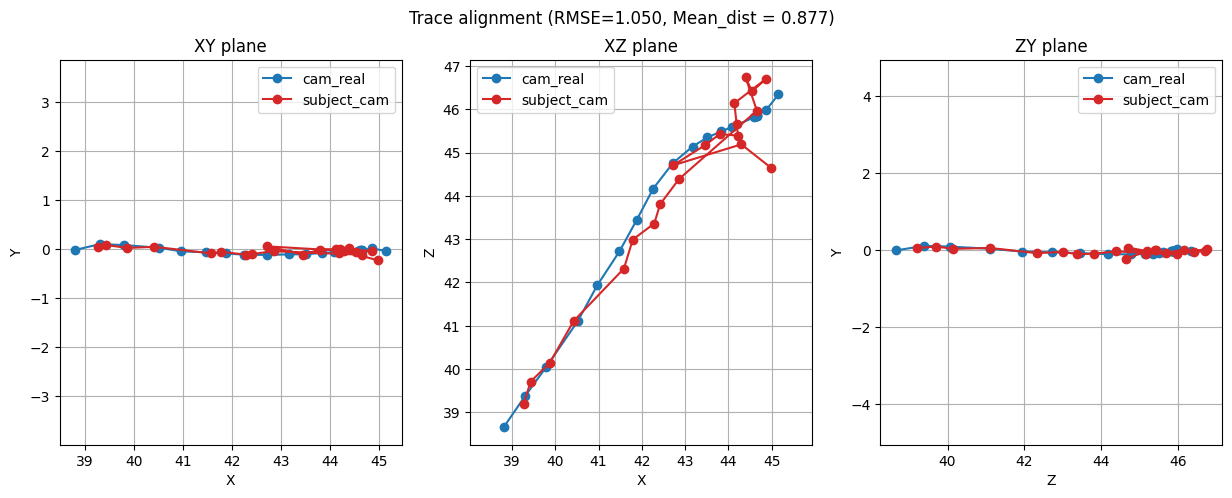

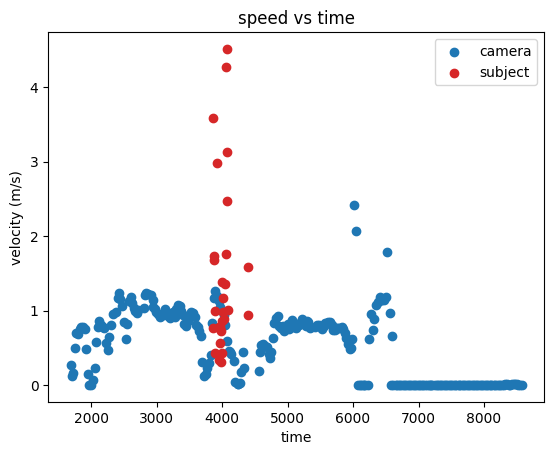

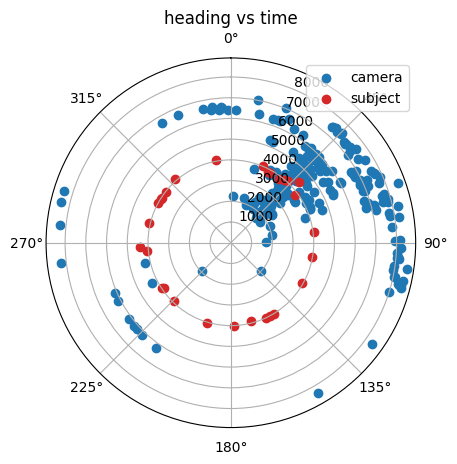

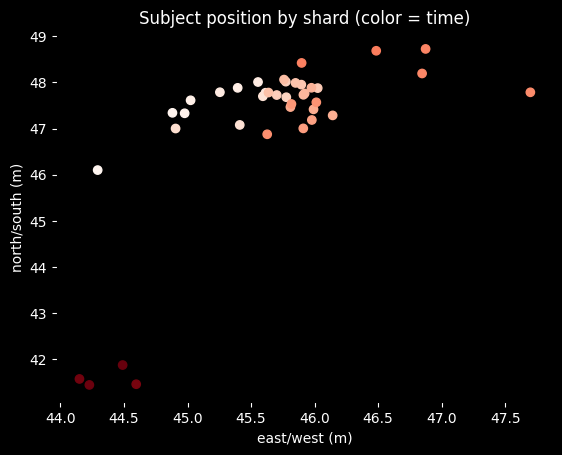

In [47]:
#LOAD VGGT_O recon for further processing
from E_post_recon_processing import Reconstruction
recon_128 = Reconstruction.load(frames_for_recon, predictions_path_128, FRAME_NAME_FMT)
#processes spatial information about the recon and the cubject  - for report and generates the data needed to map the subject
#Takes the lat and long to do mapping
#Takes the cam poses dict to conform the 3d model to the same space that the cam pose transform is in

from Q_subject_analysis import subject_to_metric_and_gps_space
from F_transforms_alignments import  recon_to_recon_transform
R_mw , s_mw, t_mw  = recon_to_recon_transform(recon ,  cam_poses_realworld_dict)
print("rescale to realwoirld",s_mw)
sub_latlon, sub_pos, sub_pos_real_dict = subject_to_metric_and_gps_space(
    recon_128,
    masks_dir        = str(yolo_masks_dir),
    lat_0=lat_0, lon_0=lon_0,
    R_mw=R_mw, s_mw =s_mw, t_mw =t_mw
    )    


        #MAKE PLYS of VGGT__O
        #turn VGGT_O output into cam0 space then scale it to metres using the output from subject_to_metric_and_gps_space
       #n.b it translates to the beginning of the camera track solve, then re-translates to the recon cam 0 space. 
_ = recon_128.VGGT_O_preds_to_ply_export(VGGT_O_output_dir  / "ply" , R=R_mw, t=t_mw, s=s_mw)
        
print(predictions_path_128)
##Graphing and analysis  
from Q_Metric_georeferencing import speed_direction, _speed_direction_single
from Q_subject_analysis import subject_reporting
fps = 30.07 #temp!
#metrics = speed_direction(cam_poses_realworld_dict, fps)
#sub_metrics = speed_direction(sub_pos_real_dict  , fps)
group_metrics = speed_direction((cam_poses_realworld_dict,sub_pos_real_dict),
                                 fps,                                 
                                 )
subject_details =   subject_reporting(sub_pos_real_dict,cam_poses_realworld_dict,lat_0, lon_0 )

#graph postions 2d
from matplotlib import pyplot as plt
# sub_rw_dicts[i] == (sub_latlon_i, sub_pos_i, sub_pos_real_dict_i)
pts = np.array([sub_pos_real_dict[k] for k in sorted(sub_pos_real_dict)])
x_0 = pts[:, 0]
y_0 = pts[:, 2]

#y_0 = sub_pos_real_dict[1][:,2]
#x_0 = sub_pos_real_dict[1][:,0]
#y_1 = sub_rw_dicts[1][1][:,2]
#x_1 = sub_rw_dicts[1][1][:,0]
#y_2 = sub_rw_dicts[2][1][:,2]
#x_2 = sub_rw_dicts[2][1][:,0]
fig, ax = plt.subplots()
fig.patch.set_facecolor("black")
ax.set_facecolor("black")

ax.scatter(x_0, y_0, c=np.arange(len(x_0)), cmap="Reds")
#ax.scatter(x_1, y_1, c=np.arange(len(x_1)), cmap="Greens")
#ax.scatter(x_2, y_2, c=np.arange(len(x_2)), cmap="Blues")

ax.tick_params(colors="white")
ax.xaxis.label.set_color("white")
ax.yaxis.label.set_color("white")
ax.title.set_color("white")
ax.set_xlabel("east/west (m)")
ax.set_ylabel("north/south (m)")
ax.set_title("Subject position by shard (color = time)")

#make animated map can do svg, giof or mp4. SVG is default

import importlib, R_map_animator

R_map_animator.main(
    traces=[
        {"coords": cam_latlons, "trail_color": "#3498db"},#cameras
        {"coords": sub_latlon,    "trail_color": "#e74c3c"},#subject
    ],
    api_key     = api_key,
    gif = True,
    mp4 = None
    

)


In [28]:
#render projection of 3D points clouds
from Rendering.U_rendering import basic_point_cloud_render
#double way to get vggt and cut3r
if VGGT_O_RECON ==True:
    visualisation_dir = case_dir   /  VGGT_O_output_dir 
    model = "VGGT_O"
   

    ply_dir = visualisation_dir / "ply"
    print(ply_dir)
    basic_point_cloud_render(
        ply_dir, model    )
    # report metric name = render name, one row per output asset (path relative to
    


/workspaces/MScPROJECT_LOCAL/Data/07_Tropea_cafe/035_VGGT_O_output/cat_03_6int_lores_2/ply
/workspaces/knuckles_drive/Data/07_Tropea_cafe/090_assets/PC_render_frames_VGGT_O


ffmpeg version 7.1.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with gcc 14.3.0 (conda-forge gcc 14.3.0-5)
  configuration: --prefix=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_h_env_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_plac --cc=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-cc --cxx=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-c++ --nm=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-nm --ar=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-ar --disable-doc --enable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libop

In [48]:

#2D projection mapping of subject to a selected view
from E_post_recon_processing import Reconstruction
from P_projection_mapping import projection_mapping_sequence
from Two2D.B_video_processing import available_frames

#Use this to project every frame in the recon
extra_indices = available_frames(frames_for_recon, FRAME_NAME_FMT)
print(extra_indices)

point_cloud_xforms = None

subject_positions = projection_mapping_sequence(
    recon         = recon_128,
    main_idx      = None,
    #extra_indices = range (3854,4397),
      #other syntax  [400,4027, 4052, 4065],
    extra_indices = extra_indices, #- for composite (double [[]])
    #masks_dir     = str(yolo_masks_dir),
    new_view = ext_1 ,
    confidence_threshold = 0
    
       )


[3854, 3860, 3866, 3872, 3878, 3884, 3890, 3893, 3902, 3908, 3914, 3920, 3924, 3932, 3938, 3944, 3950, 3956, 3962, 3968, 3974, 3980, 3986, 3992, 3998, 4004, 4010, 4016, 4022, 4028, 4034, 4040, 4046, 4052, 4058, 4064, 4070, 4076, 4082, 4088, 4094, 4100, 4106, 4112, 4118, 4124, 4130, 4136, 4142, 4148, 4154, 4160, 4166, 4172, 4178, 4184, 4190, 4196, 4202, 4208, 4214, 4220, 4226, 4232, 4238, 4244, 4250, 4256, 4262, 4268, 4274, 4280, 4286, 4292, 4298, 4304, 4310, 4316, 4322, 4328, 4334, 4337, 4343, 4349, 4358, 4361, 4373, 4379, 4382, 4388, 4394, 4397]
[3854]
[3860]
[3866]
[3872]
[3878]
[3884]
[3890]
[3893]
[3902]
[3908]
[3914]
[3920]
[3924]
[3932]
[3938]
[3944]
[3950]
[3956]
[3962]
[3968]
[3974]
[3980]
[3986]
[3992]
[3998]
[4004]
[4010]
[4016]
[4022]
[4028]
[4034]
[4040]
[4046]
[4052]
[4058]
[4064]
[4070]
[4076]
[4082]
[4088]
[4094]
[4100]
[4106]
[4112]
[4118]
[4124]
[4130]
[4136]
[4142]
[4148]
[4154]
[4160]
[4166]
[4172]
[4178]
[4184]
[4190]
[4196]
[4202]
[4208]
[4214]
[4220]
[4226]
[4232]

ffmpeg version 7.1.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with gcc 14.3.0 (conda-forge gcc 14.3.0-5)
  configuration: --prefix=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_h_env_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_placehold_plac --cc=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-cc --cxx=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-c++ --nm=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-nm --ar=/home/conda/feedstock_root/build_artifacts/ffmpeg_1758923917305/_build_env/bin/x86_64-conda-linux-gnu-ar --disable-doc --enable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libop